<a href="https://colab.research.google.com/github/robsongfk/predicao-falhas-industria/blob/feature%2Ffase2-dataprep/pipeline_preditivo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Importação das bibliotecas utilizadas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

Linhas: 10000 | Colunas: 14

Tipos de Dados:
 udi                          int64
id_produto                  object
tipo                        object
temperatura_ar_k           float64
temperatura_processo_k     float64
velocidade_rotacao_rpm     float64
torque_nm                  float64
desgaste_ferramenta_min      int64
falha_maquina                int64
falha_twf                    int64
falha_hdf                    int64
falha_pwf                    int64
falha_osf                    int64
falha_rnf                    int64
dtype: object


,udi,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
count,10000.00000,9500.000000,9500.000000,9500.000000,9500.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.002158,310.000895,1539.245263,39.974168,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.001689,1.486432,180.273589,9.995453,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.100000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1504.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1613.000000,46.700000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


/tmp/ipykernel_466/149817886.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='falha_maquina', ax=axes[1], palette='Set1')


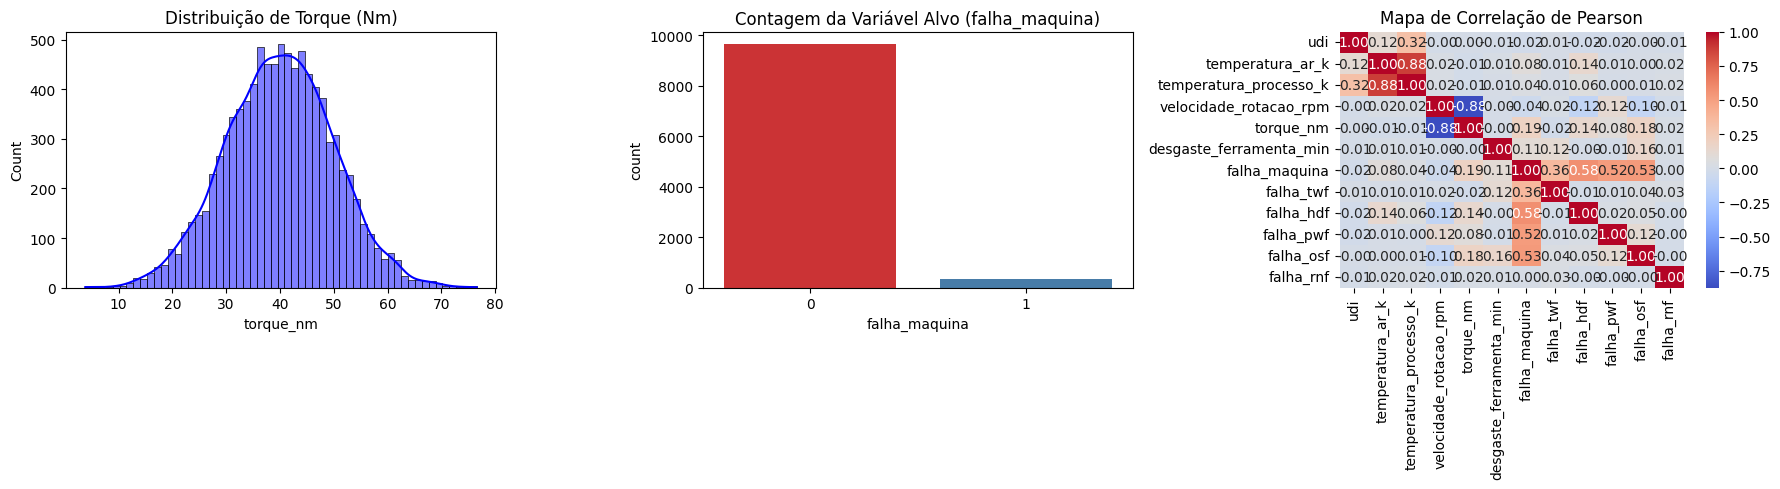

In [2]:
# Fase 1: Análise Exploratória (EDA)
# Lendo os dados (Certifique-se de que o arquivo já foi feito o upload no Colab)
df = pd.read_csv('./data/manutencao_preditiva.csv')

# 1. Dimensões do dataset
print(f"Linhas: {df.shape[0]} | Colunas: {df.shape[1]}")

# 2. Tipos de dados
print("\nTipos de Dados:\n", df.dtypes)

# 3. Resumo Estatístico
display(df.describe())

# 4. Gráficos Analíticos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: Histograma das variáveis numéricas
sns.histplot(df['torque_nm'], kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribuição de Torque (Nm)')

# Gráfico 2: Gráfico de Barras do Desbalanceamento
sns.countplot(data=df, x='falha_maquina', ax=axes[1], palette='Set1')
axes[1].set_title('Contagem da Variável Alvo (falha_maquina)')

# Gráfico 3: Mapa de Calor de Correlação Pearson (apenas colunas numéricas)
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f", ax=axes[2])
axes[2].set_title('Mapa de Correlação de Pearson')

plt.tight_layout()
plt.show()

Linhas após remoção de duplicados: 10000
Valores nulos nas colunas numéricas após tratamento:
 udi                        0
temperatura_ar_k           0
temperatura_processo_k     0
velocidade_rotacao_rpm     0
torque_nm                  0
desgaste_ferramenta_min    0
falha_maquina              0
falha_twf                  0
falha_hdf                  0
falha_pwf                  0
falha_osf                  0
falha_rnf                  0
dtype: int64


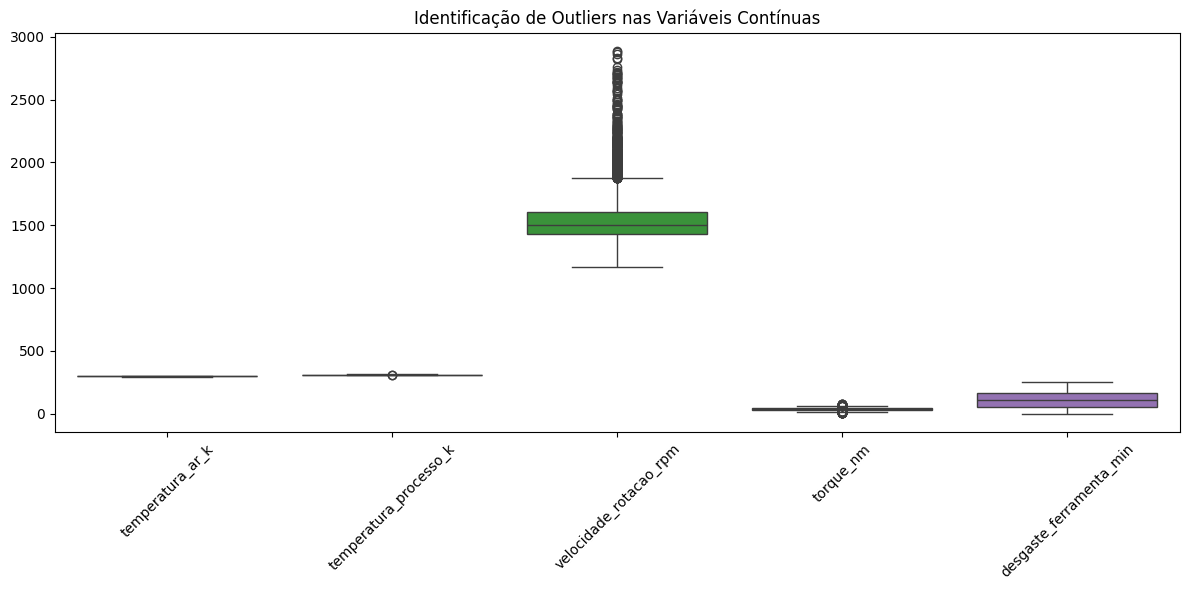

In [4]:
# Fase 2: Limpeza e Tratamento de Dados (Data Prep)

# 1. Remoção de duplicados
df.drop_duplicates(inplace=True)
print(f"Linhas após remoção de duplicados: {df.shape[0]}")

# 2. Tratamento de Ausentes
# Vamos aplicar a mediana EXCLUSIVAMENTE nas colunas numéricas para não dar erro com textos
colunas_numericas = df.select_dtypes(include=[np.number]).columns
df[colunas_numericas] = df[colunas_numericas].fillna(df[colunas_numericas].median())

print("Valores nulos nas colunas numéricas após tratamento:\n", df[colunas_numericas].isnull().sum())

# 3. Identificação de Outliers
plt.figure(figsize=(12,6))
# Filtrando apenas as colunas contínuas para o Boxplot (removendo IDs e variáveis binárias de falha para melhor visualização)
cols_para_boxplot = ['temperatura_ar_k', 'temperatura_processo_k', 'velocidade_rotacao_rpm', 'torque_nm', 'desgaste_ferramenta_min']
sns.boxplot(data=df[cols_para_boxplot])
plt.xticks(rotation=45)
plt.title('Identificação de Outliers nas Variáveis Contínuas')
plt.tight_layout()
plt.show()

**Justificativa da Imputação (Fase 2):** Optou-se pela imputação dos dados ausentes utilizando a **Mediana** em vez da Média. Como comprovado pelo gráfico de Boxplot acima (especialmente nas variáveis de velocidade de rotação e torque), existem outliers nas variáveis explicativas. A média é altamente sensível a esses valores extremos, o que distorceria os dados, enquanto a mediana é uma medida estatística robusta, sendo a escolha ideal para este cenário.